In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

Mean Squared Error: 0.03952432765754487
R^2 Score: 0.4232578991796251


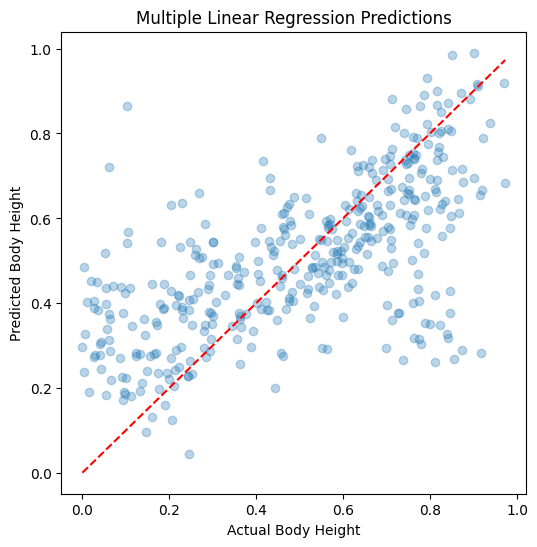

y5     3.437059
y6    -3.251649
x5     3.130465
x3    -3.044103
x6    -2.928867
x1     2.087545
y9    -1.694003
y1    -1.480603
y4     1.418112
x0    -1.342519
x9     1.326383
y10    1.085058
y18   -0.755891
y20    0.717559
x22    0.688524
dtype: float64


In [11]:
df = pd.read_csv("yoga_poses_cleaned_final.csv")

#Target variable
y = df['body_height']

#feature columns
features_cols = [col for col in df.columns
                if col.startswith('x') or col.startswith('y')]

X = df[features_cols]

training_for_X, testing_for_X, training_for_y, testing_for_y = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

training_for_X_scaled = scaler.fit_transform(training_for_X)
testing_for_X_scaled = scaler.transform(testing_for_X)

model = LinearRegression()
model.fit(training_for_X_scaled, training_for_y)

pred_for_y = model.predict(testing_for_X_scaled)

mse = mean_squared_error(testing_for_y, pred_for_y)
r2 = r2_score(testing_for_y, pred_for_y)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

plt.figure(figsize=(6,6))
plt.scatter(testing_for_y, pred_for_y, alpha=0.3)
plt.xlabel("Actual Body Height")
plt.ylabel("Predicted Body Height")
plt.title("Multiple Linear Regression Predictions")

plt.plot([testing_for_y.min(), testing_for_y.max()],
        [testing_for_y.min(), testing_for_y.max()],
        'r--')

plt.show()

coefficients = pd.Series(model.coef_, index=features_cols)\
                .sort_values(key=abs, ascending=False)

print(coefficients.head(15))